# Business Sales Performance Analysis

This project analyzes sales data to identify trends, top products, and business opportunities.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
df = pd.read_csv("Superstore.csv", encoding='latin1')

# Preview data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [18]:
# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create Month-Year column (clean format for plotting)
df['Order_Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Basic info
df.info()

Missing Values:
 Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Order_Month_Year    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9994 non-null   int64         
 1   Order ID          9994 non-null   object        
 2   Order Date        9994 non-null   datetime64[ns]
 3   Ship Date         9994 non-null   datetime64[ns]
 4   Ship Mode         9994 non-null   object        
 

In [19]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print(f"Total Revenue: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%


In [20]:
region_performance = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

print("\nRegional Performance:\n", region_performance)


Regional Performance:
                Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625


In [21]:
category_performance = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

print("\nCategory Performance:\n", category_performance)


Category Performance:
                        Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


In [22]:
top_sub_cat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Sub-Categories:\n", top_sub_cat)


Top 10 Sub-Categories:
 Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


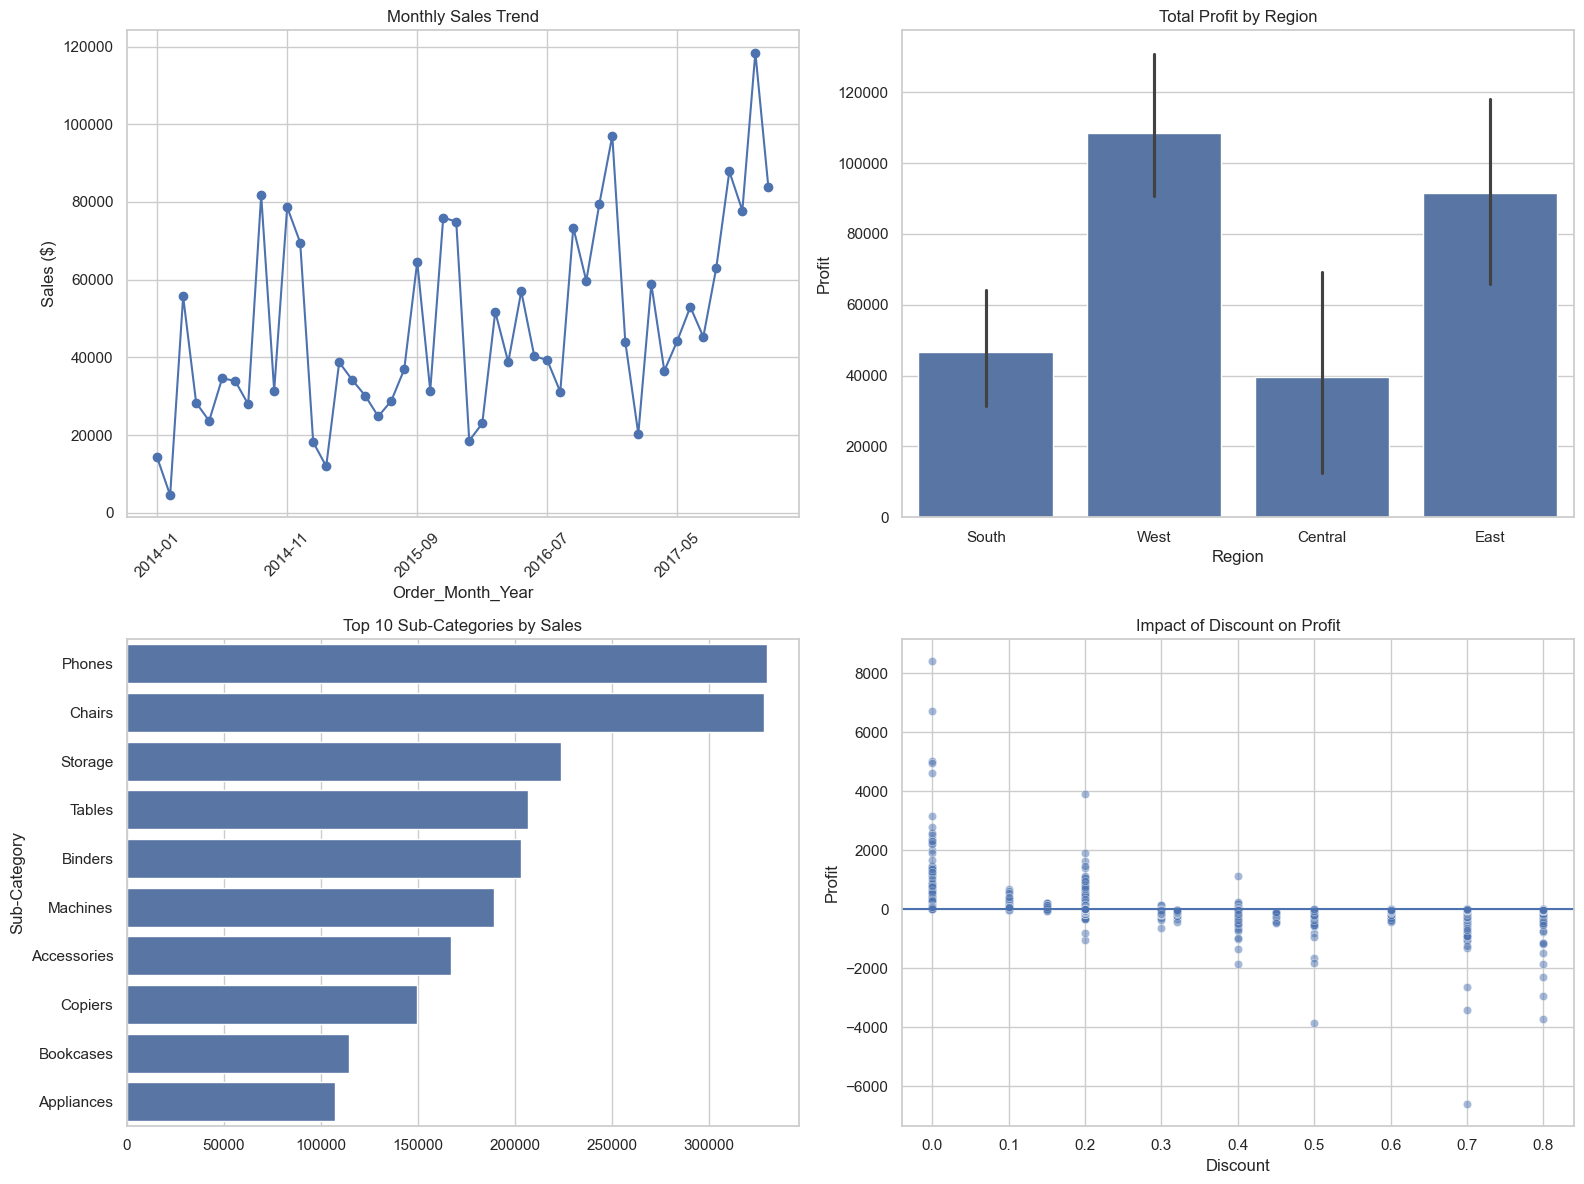

In [23]:
plt.figure(figsize=(16, 12))

# 1. Monthly Sales Trend
plt.subplot(2, 2, 1)
df.groupby('Order_Month_Year')['Sales'].sum().plot(marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)

# 2. Profit by Region
plt.subplot(2, 2, 2)
sns.barplot(data=df, x='Region', y='Profit', estimator=sum)
plt.title('Total Profit by Region')

# 3. Top 10 Sub-Categories
plt.subplot(2, 2, 3)
sns.barplot(x=top_sub_cat.values, y=top_sub_cat.index)
plt.title('Top 10 Sub-Categories by Sales')

# 4. Discount vs Profit
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.axhline(0)
plt.title('Impact of Discount on Profit')

plt.tight_layout()
plt.show()

In [27]:
# Insights based on actual analysis
print("\n--- Key Insights & Recommendations ---")

# 1. Best Region
print(f"1. The most profitable region is: {region_performance.index[0]}")

# 2. Worst Region
print(f"2. The least profitable region is: {region_performance.index[-1]}")

# 3. Top Category
print(f"3. The highest sales category is: {category_performance.index[0]}")

# 4. Loss-making situations
loss_df = df[df['Profit'] < 0]
print(f"4. Number of loss-making transactions: {len(loss_df)}")

# 5. Discount impact
high_discount_loss = df[(df['Discount'] > 0.3) & (df['Profit'] < 0)]
print(f"5. High discount loss cases (>30% discount): {len(high_discount_loss)}")

print("\n--- Business Recommendations ---")

print("• Avoid giving heavy discounts (>30%) as they often lead to losses.")
print("• Focus on top-performing categories to maximize revenue.")
print("• Investigate loss-making products and reduce their discounting.")
print("• Strengthen strategy in low-performing regions.")
print("• Use monthly sales trends to plan seasonal marketing campaigns.")


--- Key Insights & Recommendations ---
1. The most profitable region is: West
2. The least profitable region is: Central
3. The highest sales category is: Technology
4. Number of loss-making transactions: 1871
5. High discount loss cases (>30% discount): 1140

--- Business Recommendations ---
• Avoid giving heavy discounts (>30%) as they often lead to losses.
• Focus on top-performing categories to maximize revenue.
• Investigate loss-making products and reduce their discounting.
• Strengthen strategy in low-performing regions.
• Use monthly sales trends to plan seasonal marketing campaigns.


In [28]:
loss_products = df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].sum().sort_values()

print("\nTop Loss-Making Sub-Categories:\n", loss_products.head())


Top Loss-Making Sub-Categories:
 Sub-Category
Binders     -38510.4964
Tables      -32412.1483
Machines    -30118.6682
Bookcases   -12152.2060
Chairs       -9880.8413
Name: Profit, dtype: float64
